Defaulting to user installation because normal site-packages is not writeable
distutils: /home/ach18313ka/.local/lib/python3.9/site-packages
sysconfig: /home/ach18313ka/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None
20 個のファイルを検出しました: ['acc-checkpoint-100.jsonl', 'acc-checkpoint-200.jsonl', 'acc-checkpoint-300.jsonl', 'acc-checkpoint-400.jsonl', 'acc-checkpoint-500.jsonl', 'acc-checkpoint-600.jsonl', 'acc-checkpoint-700.jsonl', 'acc-checkpoint-800.jsonl', 'acc-checkpoint-900.jsonl', 'acc-checkpoint-1000.jsonl', 'acc-checkpoint-1100.jsonl', 'acc-checkpoint-1200.jsonl', 'acc-checkpoint-1300.jsonl', 'acc-checkpoint-1400.jsonl', 'acc-checkpoint-1500.jsonl', 'acc-checkpoint-1600.jsonl', 'acc-checkpoint-1700.jsonl', 'acc-checkpoint-1800.jsonl', 'acc-checkpoint-1900.jsonl', 'acc-checkpoint-1960.jsonl']
=== Overall Metrics Comparison ===


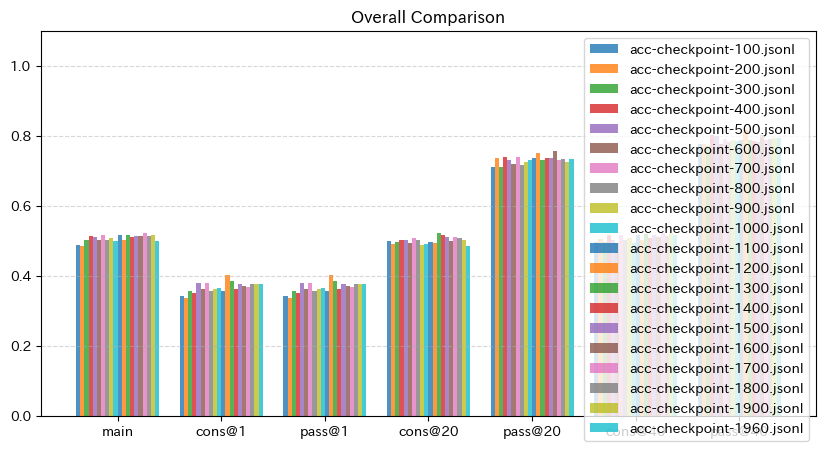


=== Category Comparison by Metric ===


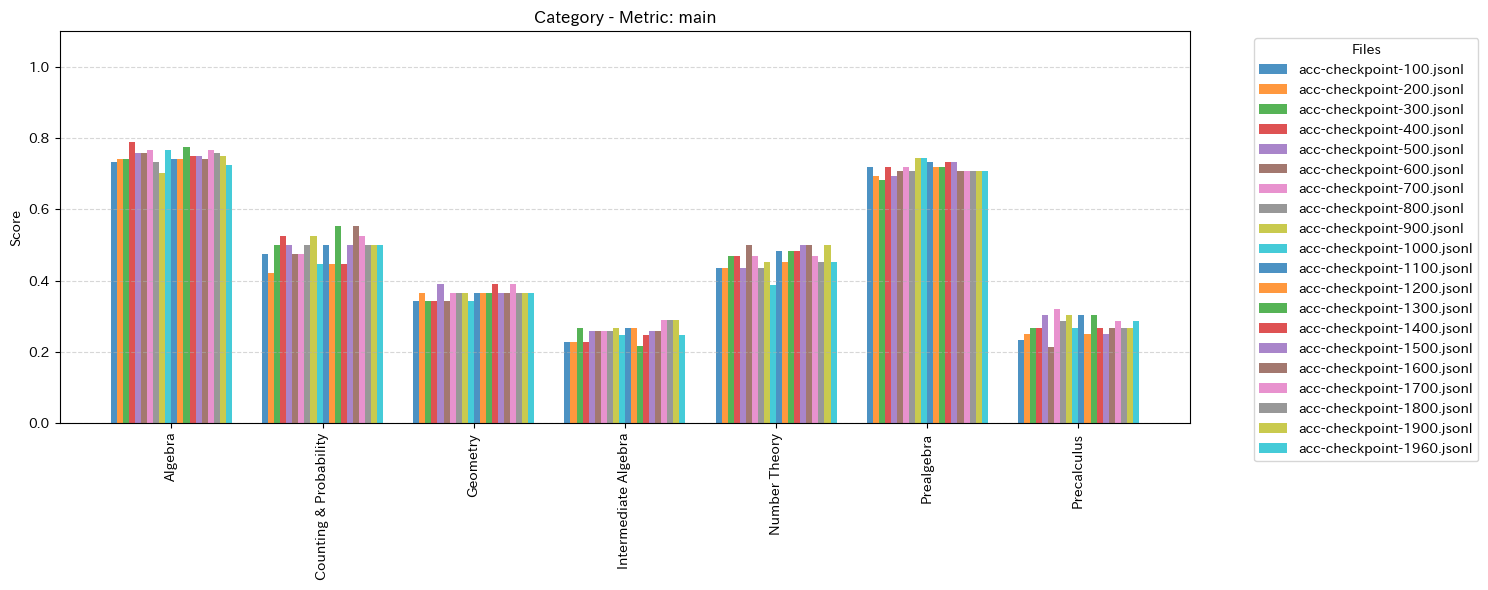

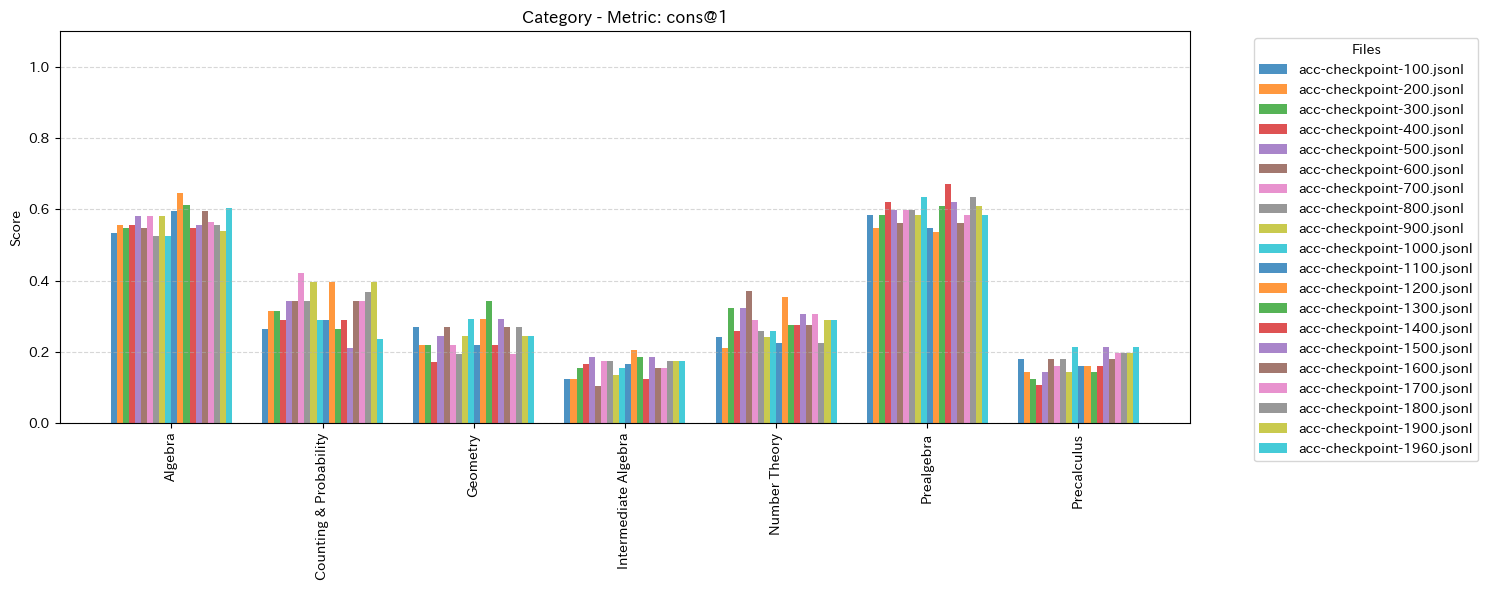

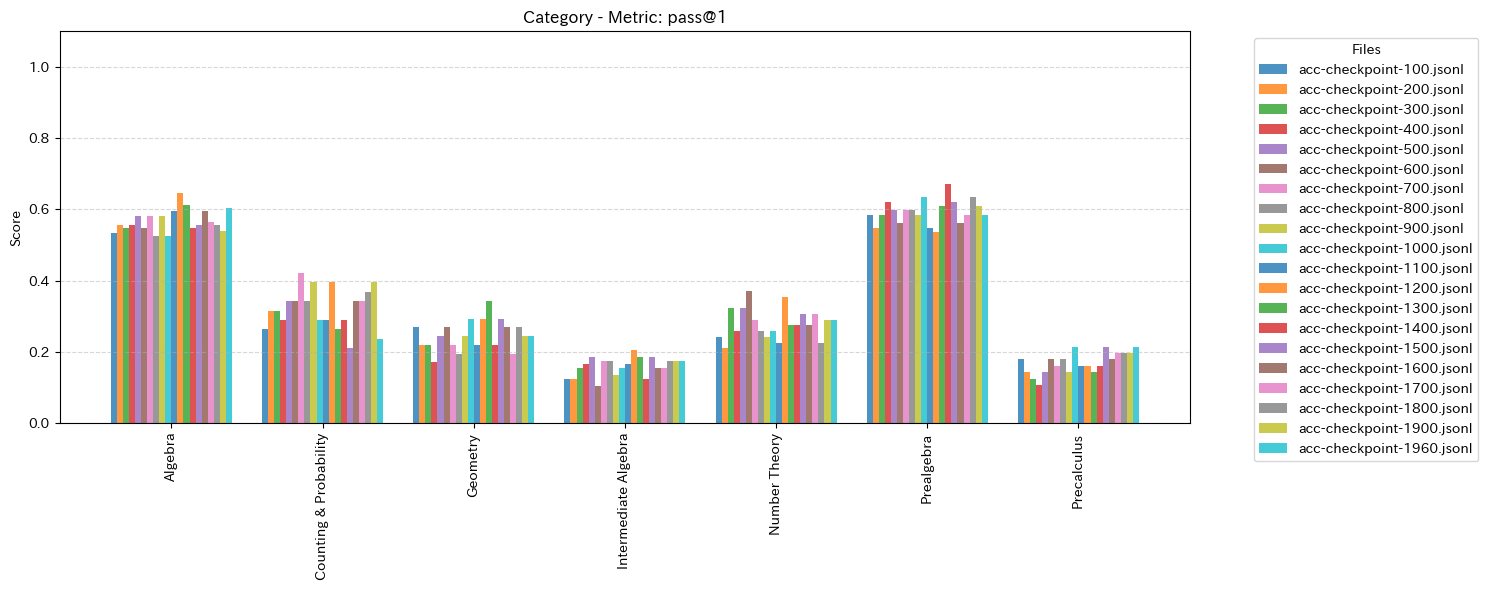

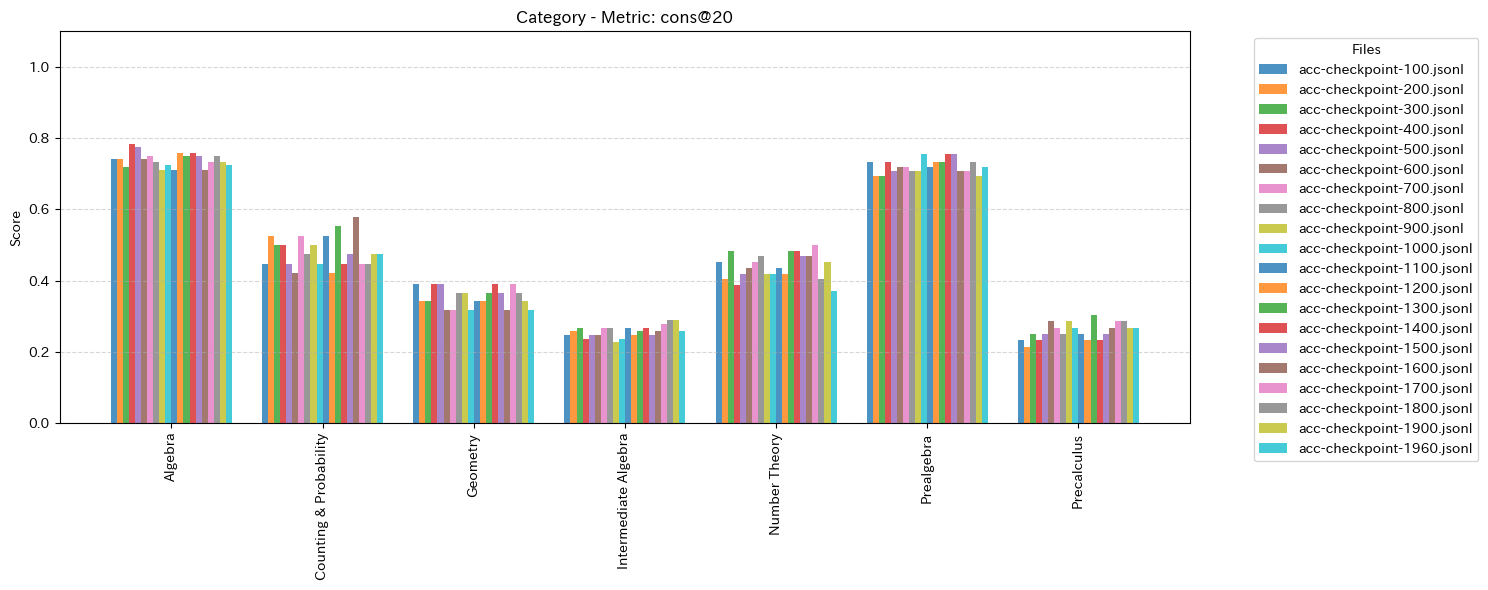

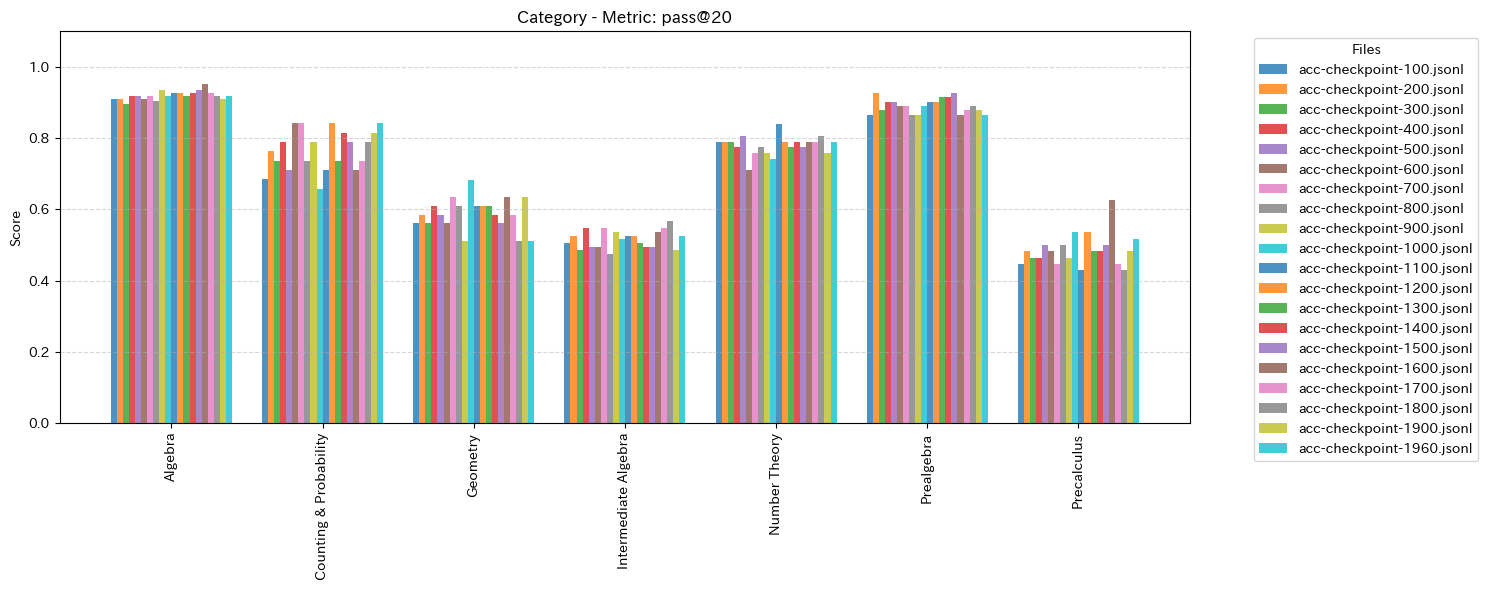

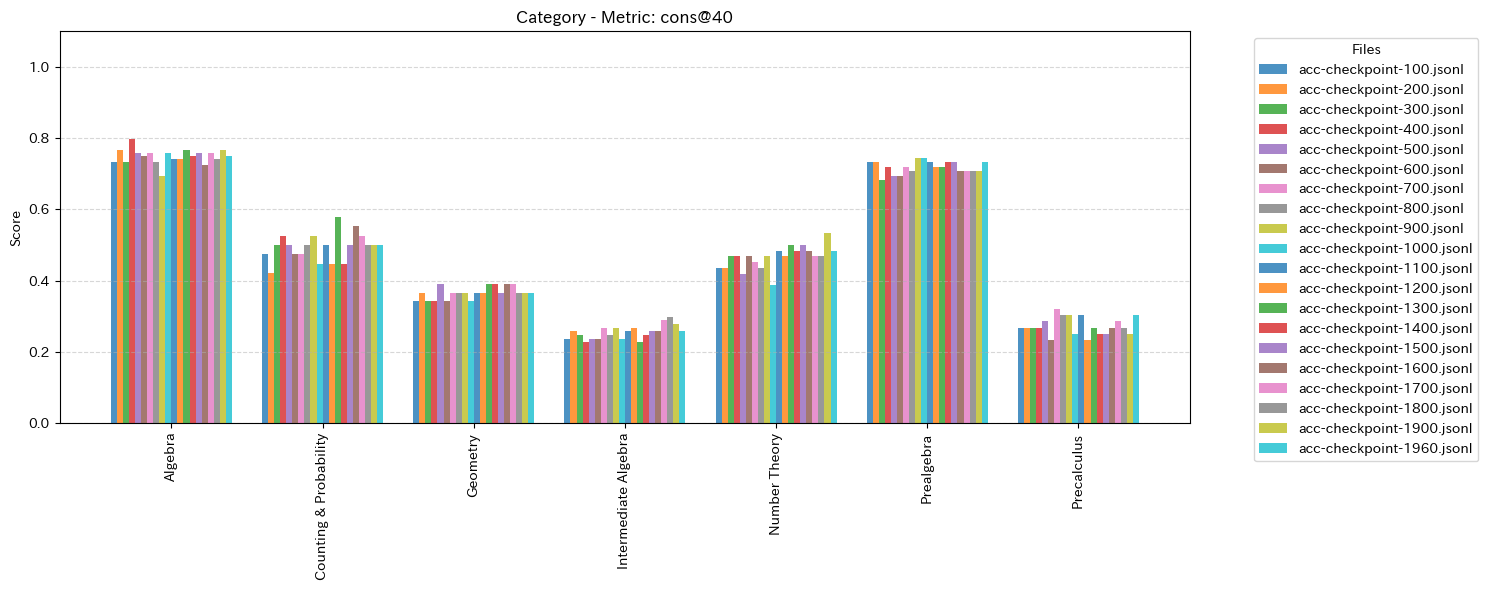

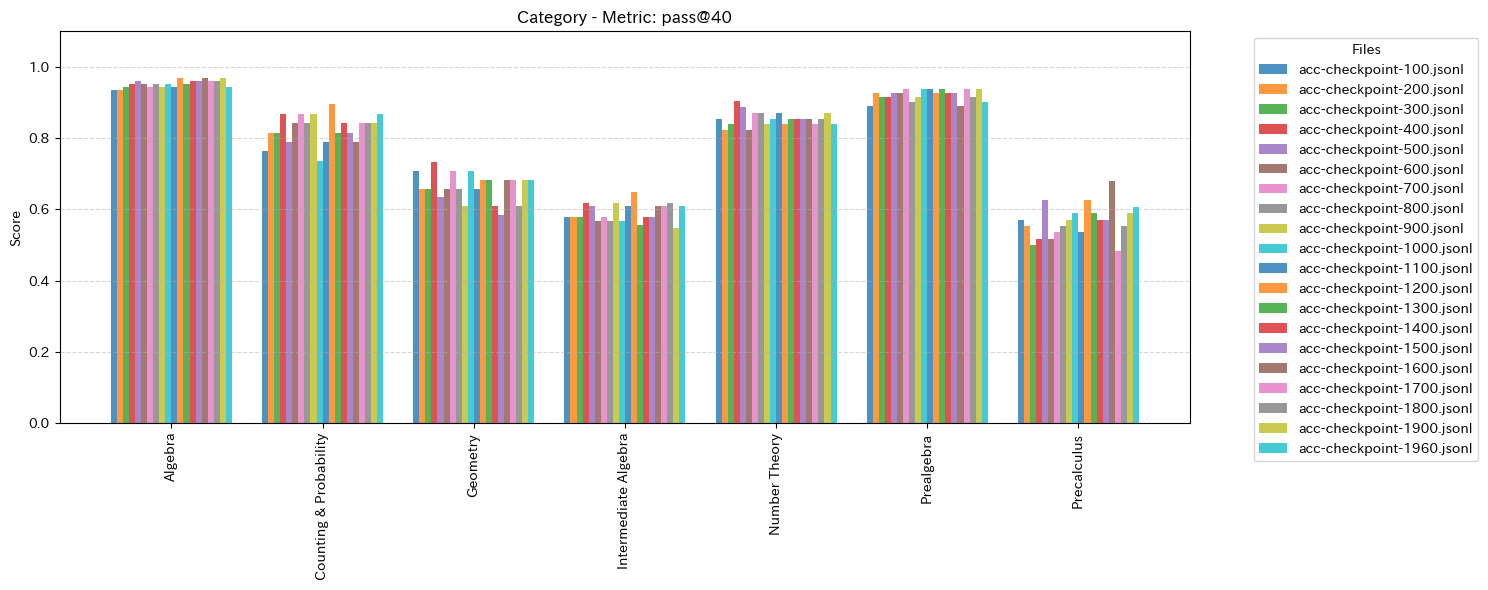


=== Unit Comparison by Metric ===


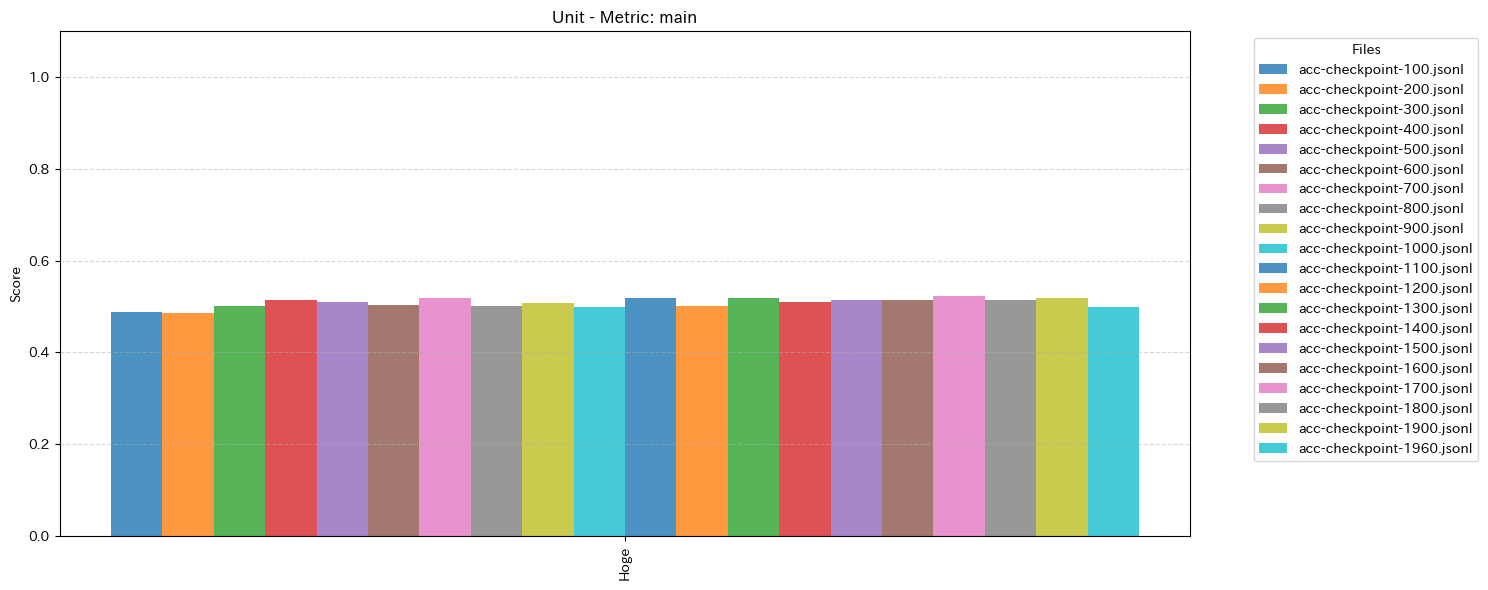

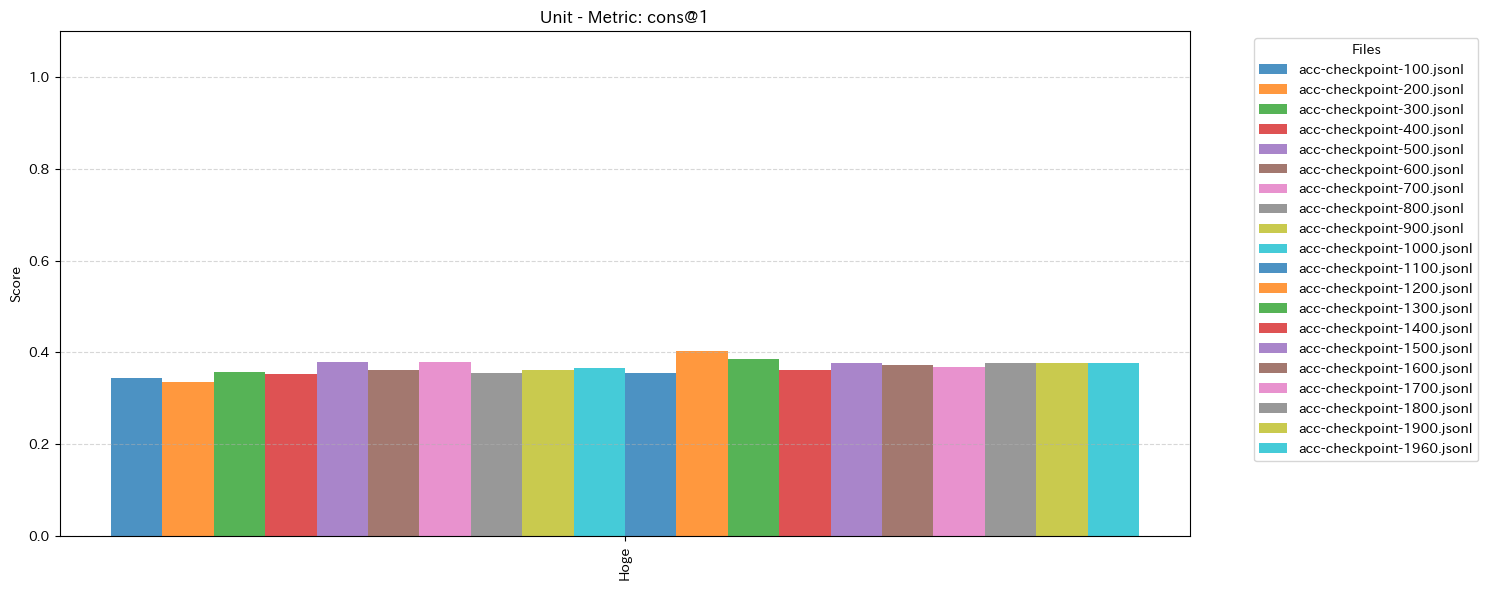

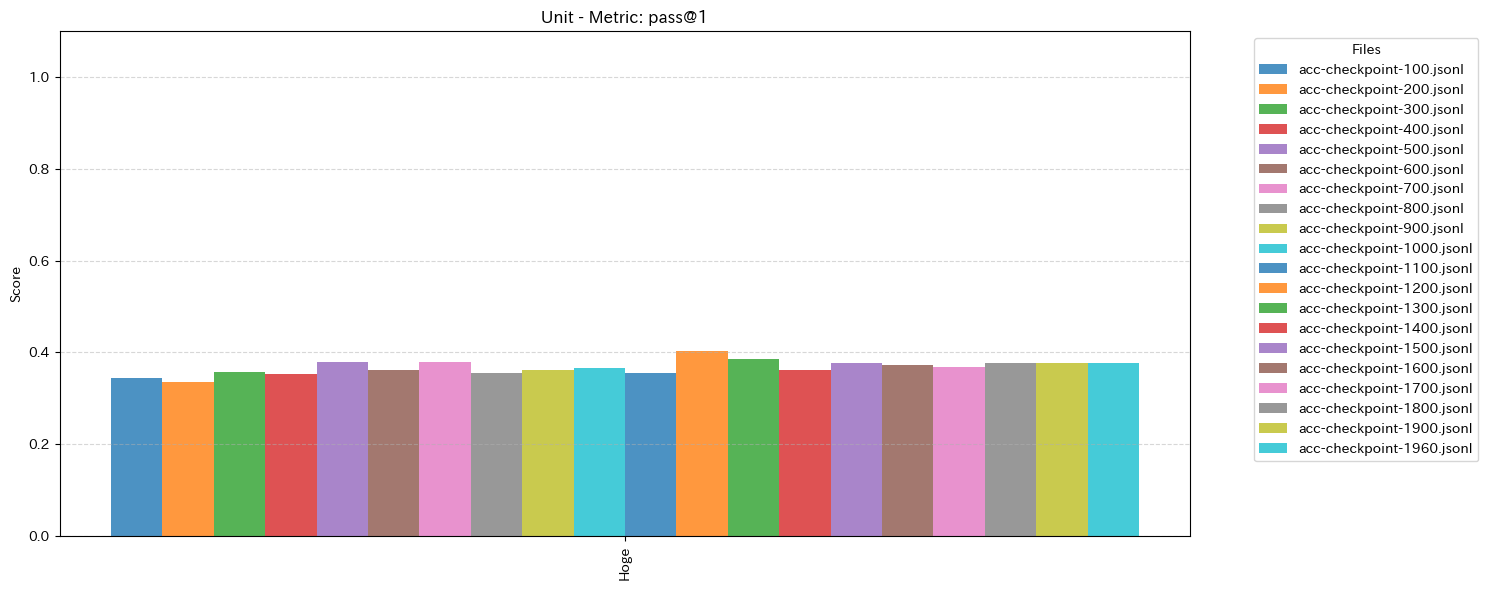

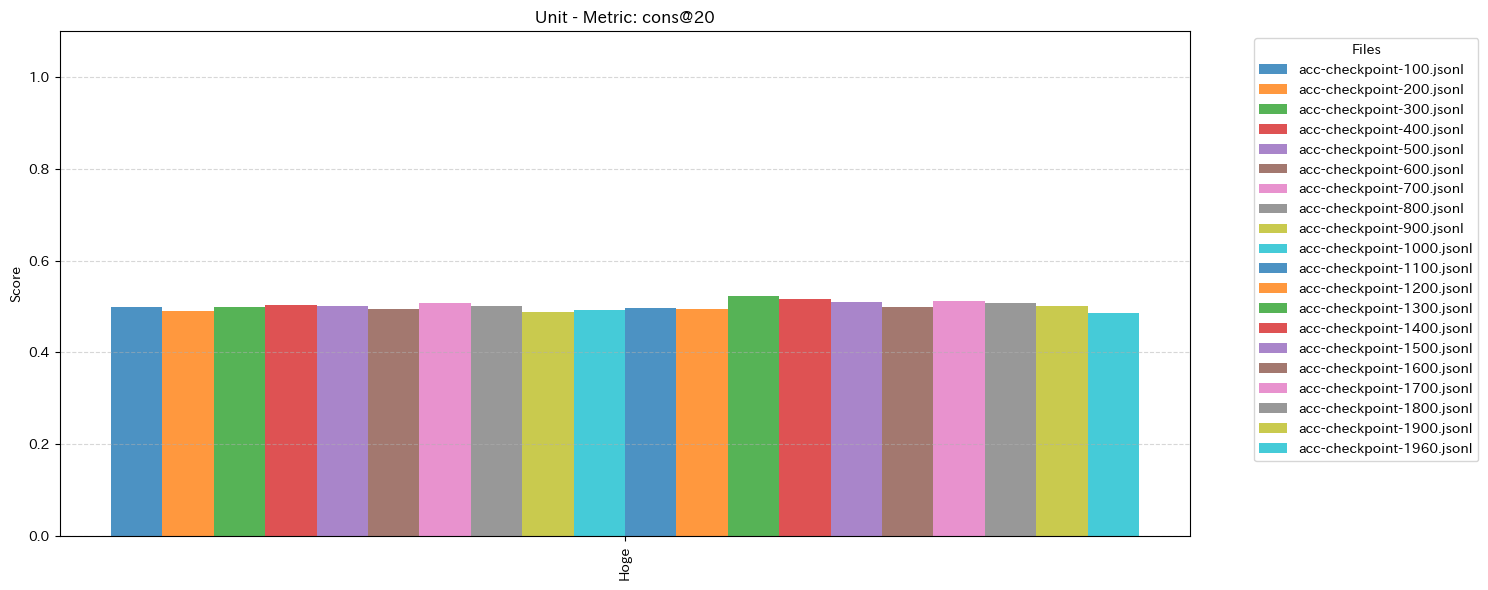

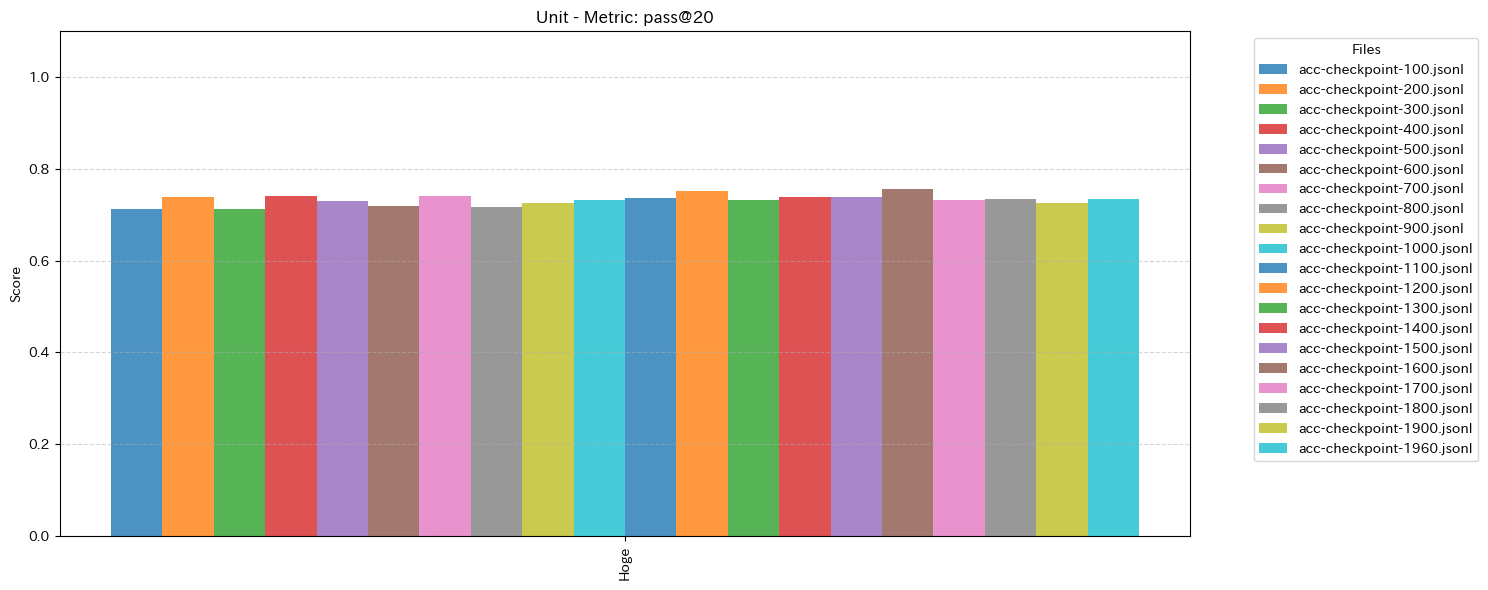

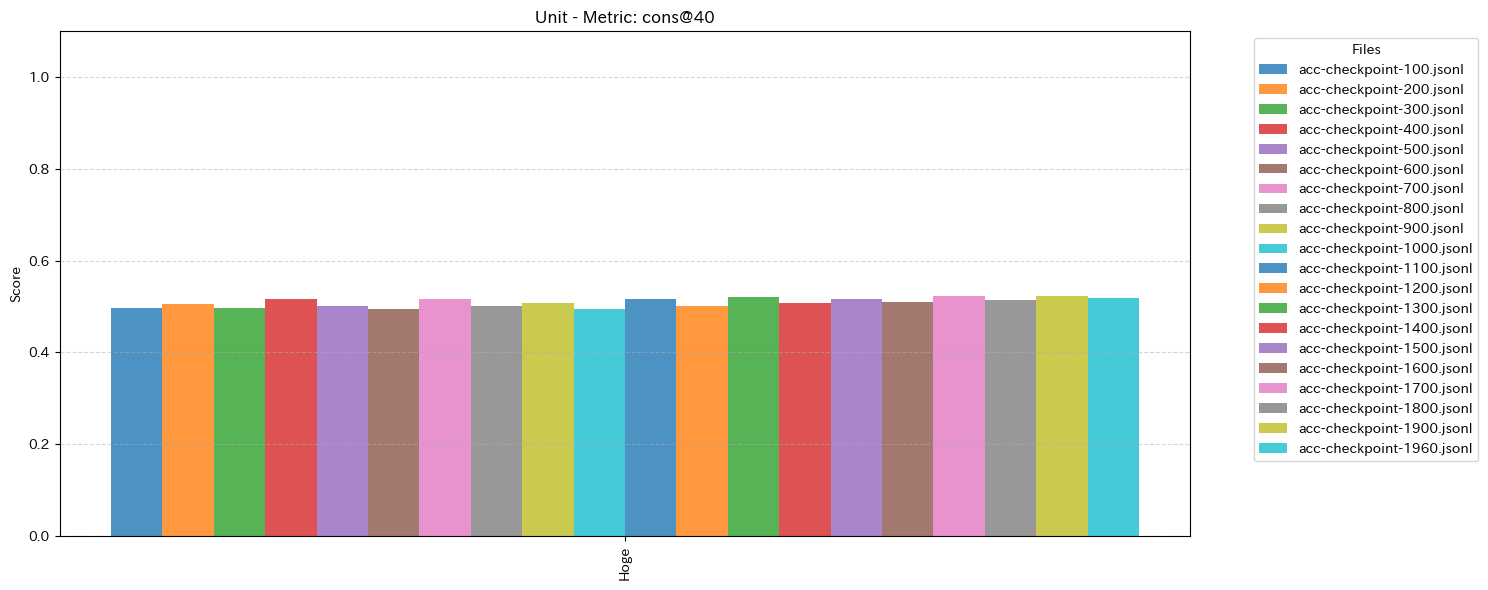

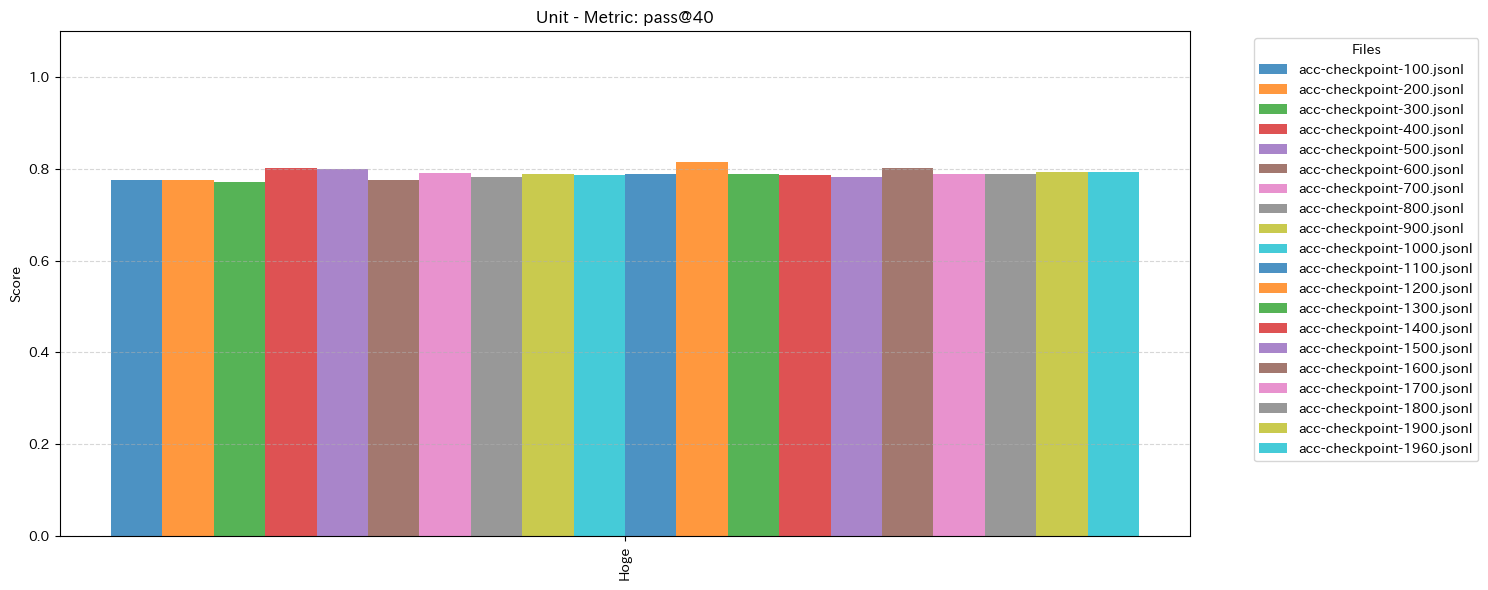

In [1]:
!pip install matplotlib japanize-matplotlib numpy

import json
import glob
import os
import matplotlib.pyplot as plt
import numpy as np

# 日本語フォントの設定（環境に合わせて調整してください）
import japanize_matplotlib
# plt.rcParams['font.family'] = 'sans-serif'
# Windows等の場合
# plt.rcParams['font.family'] = 'MS Gothic'

# ==========================================
# 1. 設定とファイルのロード
# ==========================================

# JSONファイルが格納されているディレクトリのパス（適宜変更してください）
# 例: 現在のディレクトリなら './*.json'
file_pattern = './jsons/*.jsonl' 

# 読み込むファイルパスのリストを取得
file_paths = glob.glob(file_pattern)
# sort file paths 数字の大きさで
file_paths.sort(key=lambda x: int(''.join(filter(str.isdigit, os.path.basename(x))) or 0))

if not file_paths:
    print(f"エラー: 指定されたパターン '{file_pattern}' に一致するJSONファイルが見つかりませんでした。")
    print("ディレクトリにJSONファイルを配置するか、パスを確認してください。")
    # テスト用に空リストで続行しないように停止（実際にはここで処理を終えるか、ダミーを入れるかですが、指示通りダミーなしとします）
else:
    print(f"{len(file_paths)} 個のファイルを検出しました: {[os.path.basename(f) for f in file_paths]}")

# データをロード
loaded_data = []
file_names = []

for path in file_paths:
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            loaded_data.append(data)
            # ファイル名を凡例（ラベル）として使用
            file_names.append(os.path.basename(path))
    except Exception as e:
        print(f"ファイル {path} の読み込みに失敗しました: {e}")

# 比較したい指標のリスト
TARGET_METRICS = ["main", "cons@1", "pass@1", "cons@20", "pass@20", "cons@40", "pass@40"]

# ==========================================
# 2. プロット関数の定義
# ==========================================

def plot_grouped_bar_by_metric(scope_name, items_list, scope_data_extractor):
    """
    指定されたスコープ（CategoriesやUnits）について、指標ごとにグラフを作成する関数。
    横軸にItem（単元名など）、縦軸にスコアをとる。
    
    Args:
        scope_name (str): グラフタイトルの接頭辞（例: "By Unit"）
        items_list (list): 横軸に並べる項目名のリスト（例: 全単元名のリスト）
        scope_data_extractor (func): (file_data, item_name) -> metrics_dict を返す関数
    """
    
    if not items_list or not loaded_data:
        return

    # 指標（main, pass@1...）ごとにループしてグラフを作成
    for metric in TARGET_METRICS:
        fig, ax = plt.subplots(figsize=(15, 6)) # 横長にして見やすく
        
        x = np.arange(len(items_list))
        width = 0.8 / len(loaded_data) # ファイル数に合わせて棒の幅を調整
        
        # ファイル（モデル）ごとに棒グラフを追加
        for i, (data, fname) in enumerate(zip(loaded_data, file_names)):
            values = []
            for item in items_list:
                # 該当項目のメトリクスを取得
                metrics = scope_data_extractor(data, item)
                # 該当指標の値を取得（なければ0）
                values.append(metrics.get(metric, 0))
            
            # 棒の描画
            offset = (i - len(loaded_data)/2) * width + width/2
            ax.bar(x + offset, values, width, label=fname, alpha=0.8)

        # グラフの装飾
        ax.set_title(f"{scope_name} - Metric: {metric}")
        ax.set_ylabel('Score')
        ax.set_xticks(x)
        # 画像のようにラベルを90度回転させて表示
        ax.set_xticklabels(items_list, rotation=90)
        ax.set_ylim(0, 1.1)
        ax.legend(title="Files", bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()

# ==========================================
# 3. 実行：各観点での可視化
# ==========================================

if loaded_data:
    # --- 1. Overall (全体) の比較 ---
    # Overallは項目が1つだけなので、指標を横軸にとったグラフを1つ出す（前回の形式）
    print("=== Overall Metrics Comparison ===")
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(TARGET_METRICS))
    width = 0.8 / len(loaded_data)

    for i, (data, fname) in enumerate(zip(loaded_data, file_names)):
        overall = data["metrics"].get("overall", {})
        values = [overall.get(m, 0) for m in TARGET_METRICS]
        offset = (i - len(loaded_data)/2) * width + width/2
        ax.bar(x + offset, values, width, label=fname, alpha=0.8)

    ax.set_title("Overall Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(TARGET_METRICS)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

    # --- 2. Categories (カテゴリ別) の比較 ---
    print("\n=== Category Comparison by Metric ===")
    # 全カテゴリ名を収集
    all_categories = sorted(list(set().union(*[d["metrics"].get("categories", {}).keys() for d in loaded_data])))
    
    # カテゴリデータ抽出関数
    def get_category_metrics(data, cat_name):
        return data["metrics"].get("categories", {}).get(cat_name, {})

    plot_grouped_bar_by_metric("Category", all_categories, get_category_metrics)

    # --- 3. Units (単元別) の比較 ---
    print("\n=== Unit Comparison by Metric ===")
    # 全単元名を収集
    all_units = sorted(list(set().union(*[d["metrics"].get("units", {}).keys() for d in loaded_data])))
    
    # 単元データ抽出関数
    def get_unit_metrics(data, unit_name):
        return data["metrics"].get("units", {}).get(unit_name, {})

    # 画像のようなスタイルで描画（指標ごとに、全Unitを横並び）
    plot_grouped_bar_by_metric("Unit", all_units, get_unit_metrics)

else:
    print("データがロードされなかったため、グラフを作成できませんでした。")